In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random, os, math, urllib.request
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import spectral_norm as SN
from torch.utils.data import DataLoader
import torchvision.transforms as T
from torchvision.datasets import CIFAR10
from torchvision.utils import make_grid
from scipy import linalg
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
Z_DIM = 100
def show_samples(G, z_dim=Z_DIM, n=64, title=''):
    G.eval()
    with torch.no_grad():
        z = torch.randn(n, z_dim, 1, 1, device=device)
        imgs = G(z).cpu()
    grid = make_grid(imgs*0.5+0.5)
    plt.figure(figsize=(10,10))
    plt.imshow(grid.permute(1,2,0).numpy())
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()
    G.train()

## DCGAN

In [3]:
class DCGANGenerator(nn.Module):
    def __init__(self, nz=Z_DIM, ngf=64, nc=3):
        super().__init__()
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            nn.ConvTranspose2d(     nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # state size. (ngf*8) x 4 x 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # state size. (ngf*4) x 8 x 8
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state size. (ngf*2) x 16 x 16
            nn.ConvTranspose2d(ngf * 2,     ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(    ngf,      nc, kernel_size=1, stride=1, padding=0, bias=False),
            nn.Tanh()
        )
    def forward(self, z):
        return self.main(z)  # (B,3,32,32)

class DCGANDiscriminator(nn.Module):
    def __init__(self, ndf=64, nc=3):
        super().__init__()
        self.main = nn.Sequential(
            # input is (nc) x 64 x 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf) x 32 x 32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*2) x 16 x 16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*4) x 8 x 8
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*8) x 4 x 4
            nn.Conv2d(ndf * 8, 1, 2, 2, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x).view(-1)  # (B,)
dcgan_G = DCGANGenerator().to(device)
dcgan_D = DCGANDiscriminator().to(device)
dcgan_G.load_state_dict(torch.load('./weights/dcgan_G.pt', map_location=device, weights_only=True))
dcgan_D.load_state_dict(torch.load('./weights/dcgan_D.pt', map_location=device, weights_only=True))

<All keys matched successfully>

## WGAN-GP

In [4]:
class WGANCritic(nn.Module):
    def __init__(self, ndf=64, nc=3):
        super().__init__()
        cfgs = [(nc, ndf), (ndf, ndf*2), (ndf*2, ndf*4), (ndf*4, ndf*8)]
        layers = [l for ci,co in cfgs for l in [nn.Conv2d(ci, co, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, True)]]
        layers += [nn.Conv2d(ndf*8, 1, 2, 2, 0, bias=False)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).view(-1)  # (B,)
wgan_G = DCGANGenerator().to(device)
wgan_D = WGANCritic().to(device)
wgan_G.load_state_dict(torch.load('./weights/wgan_G.pt', map_location=device, weights_only=True))
wgan_D.load_state_dict(torch.load('./weights/wgan_D.pt', map_location=device, weights_only=True))

<All keys matched successfully>

## DCGAN-SN

In [5]:
class SNGANDiscriminator(nn.Module):
    def __init__(self, ndf=64, nc=3):
        super().__init__()
        cfgs = [(nc, ndf), (ndf, ndf*2), (ndf*2, ndf*4), (ndf*4, ndf*8)]
        layers = [l for ci,co in cfgs for l in [SN(nn.Conv2d(ci, co, 4, 2, 1, bias=False)), nn.LeakyReLU(0.2, True)]]
        layers += [SN(nn.Conv2d(ndf*8, 1, 2, 2, 0, bias=False)), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).view(-1)
sngan_G = DCGANGenerator().to(device)
sngan_D = SNGANDiscriminator().to(device)
sngan_G.load_state_dict(torch.load('./weights/sngan_G.pt', map_location=device, weights_only=True))
sngan_D.load_state_dict(torch.load('./weights/sngan_D.pt', map_location=device, weights_only=True))

<All keys matched successfully>

## Sample

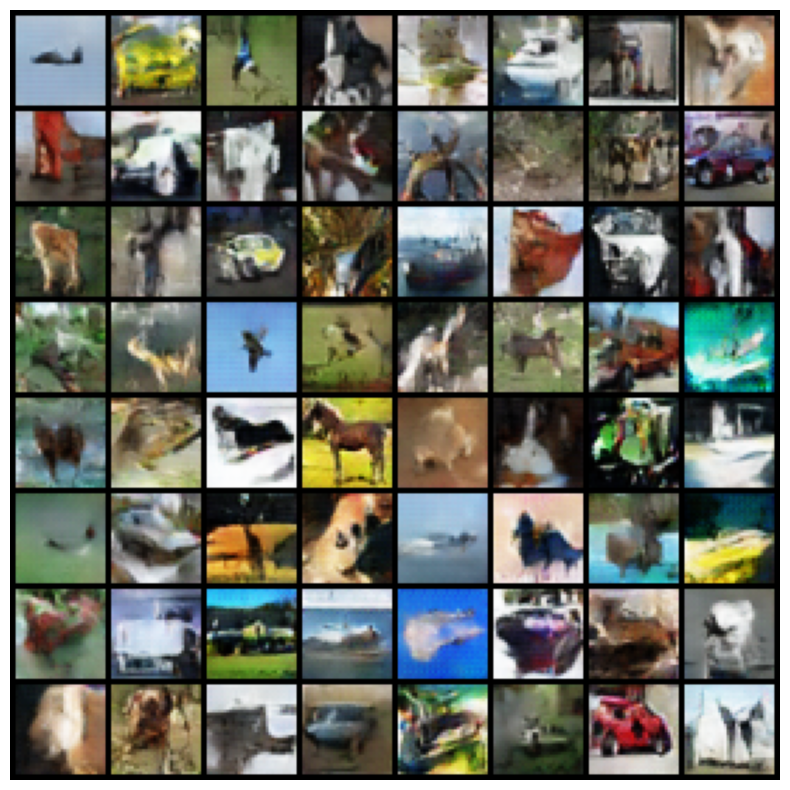

In [6]:
model = wgan_G
show_samples(model)